# Assignment 4: Support Vector Machine (SVM) and Model Ensemble {-}

This assignment aims at familiarizing you with training and testing Suppor Vector Machine classification model, along with exploiting the power of model ensemble technics. Here are the BASIC requirements of the assignment:

- Load the data.
- Analyze the data.
- Remove outliers and clean the data.
- Use GridSearchCV to find the best set of SVM hyperparameters.
- Build, train and evaluate the SVM model.
- Separately build, train and evaluate the other four classifiers (Logistic regression, Naive Bayes, Decision Tree, Random Forest) on the same dataset, then compare their performance with the SVM model's.
- Apply three model ensemble technics, i.e., Bagging, Boosting and Stacking, to solve the problem, then compare their performance with each other and with the use of individual models. Draw conclusion from what has been observed.

The dataset you will be working on is 'data-breast-cancer.csv'. It is composed of attributes to build a prediction model.

### Submission {-}
The structure of submission folder should be organized as follows:

- ./\<StudentID>-assignment4-notebook.ipynb: Jupyter notebook containing source code.

The submission folder is named ML4DS-\<StudentID>-Assignment4 (e.g., ML4DS-2012345-Assigment4) and then compressed with the same name.
    
### Evaluation {-}
Assignment evaluation will be conducted on how you accomplish the assignment requirements. It is a plus if you have data exploration and modeling steps other than the basic requirements. In addition, your code should conform to a Python coding convention such as PEP-8.

### Deadline {-}
Please visit Canvas for details.

In [1]:
# Load the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Load the dataset
df = pd.read_csv("data-breast-cancer.csv")

In [3]:
# Show some data samples
df.head()

,Unnamed: 0,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean
0,0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871
1,1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667
2,2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999
3,3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744
4,4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883


This is a dataset used to detect whether a patient has breast cancer depending on the following features: 

- diagnosis: (label) the diagnosis of breast (label) tissues (M = malignant, B = benign).
- radius: distances from center to points on the perimeter.
- texture: standard deviation of gray-scale values.
- perimeter: perimeter of the tumor.
- area: area of the tumor.
- smoothness: local variation in radius lengths.
- compactness: is equal to (perimeter^2 / area - 1.0).
- concavity: severity of concave portions of the contour.
- concave points: number of concave portions of the contour.
- symmetry: symmetry of the tumor shape.
- fractal dimension: "coastline approximation" - 1.



## Data analysis and cleaning

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Unnamed: 0              569 non-null    int64  
 1   diagnosis               569 non-null    object 
 2   radius_mean             569 non-null    float64
 3   texture_mean            569 non-null    float64
 4   perimeter_mean          569 non-null    float64
 5   area_mean               569 non-null    float64
 6   smoothness_mean         569 non-null    float64
 7   compactness_mean        569 non-null    float64
 8   concavity_mean          569 non-null    float64
 9   concave points_mean     569 non-null    float64
 10  symmetry_mean           569 non-null    float64
 11  fractal_dimension_mean  569 non-null    float64
dtypes: float64(10), int64(1), object(1)
memory usage: 53.5+ KB


In [5]:
df.drop('Unnamed: 0', axis = 1, inplace=True)

In [6]:
# Drop duplicate samples
df = df.drop_duplicates(ignore_index=True)     # ignore_index=True means the resulting axis will be labeled 0, 1, ..., n-1, otherwise there will be index gaps. Try df = df.drop_duplicates(), then df.head(1000) to see the difference.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   diagnosis               569 non-null    object 
 1   radius_mean             569 non-null    float64
 2   texture_mean            569 non-null    float64
 3   perimeter_mean          569 non-null    float64
 4   area_mean               569 non-null    float64
 5   smoothness_mean         569 non-null    float64
 6   compactness_mean        569 non-null    float64
 7   concavity_mean          569 non-null    float64
 8   concave points_mean     569 non-null    float64
 9   symmetry_mean           569 non-null    float64
 10  fractal_dimension_mean  569 non-null    float64
dtypes: float64(10), object(1)
memory usage: 49.0+ KB


array([[<Axes: title={'center': 'radius_mean'}>,
        <Axes: title={'center': 'texture_mean'}>,
        <Axes: title={'center': 'perimeter_mean'}>,
        <Axes: title={'center': 'area_mean'}>,
        <Axes: title={'center': 'smoothness_mean'}>],
       [<Axes: title={'center': 'compactness_mean'}>,
        <Axes: title={'center': 'concavity_mean'}>,
        <Axes: title={'center': 'concave points_mean'}>,
        <Axes: title={'center': 'symmetry_mean'}>,
        <Axes: title={'center': 'fractal_dimension_mean'}>]], dtype=object)

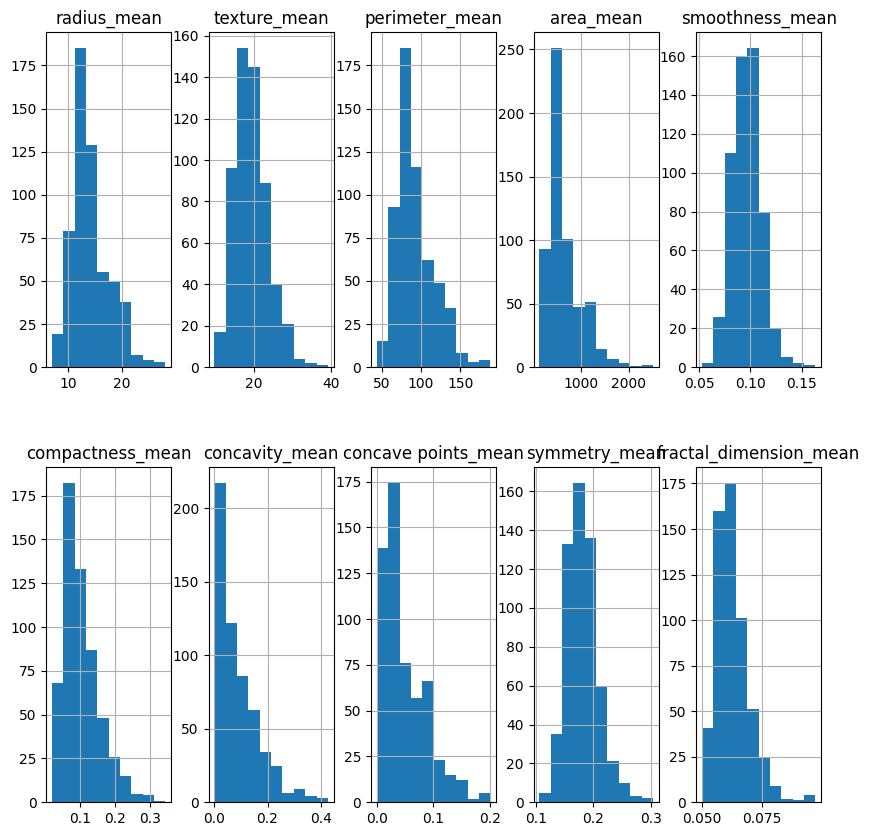

In [7]:
fig, axis = plt.subplots(2, 5, figsize=(10,10))
df.hist(ax = axis)

In [8]:
df.describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440


The data is not very beautiful. All have outliears, and some demonstrate extreme noise such as "Concave points_mean".

I will use the IQR method to remove outliear, although it does not guarantee that all outliears of this dataset can be removed. 

<Figure size 640x480 with 0 Axes>

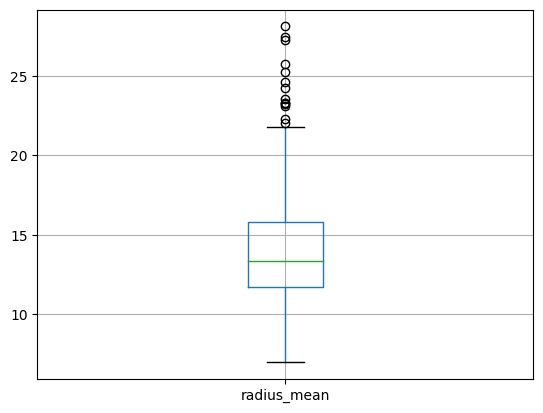

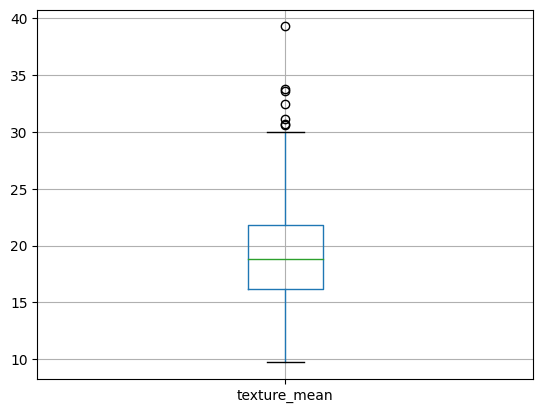

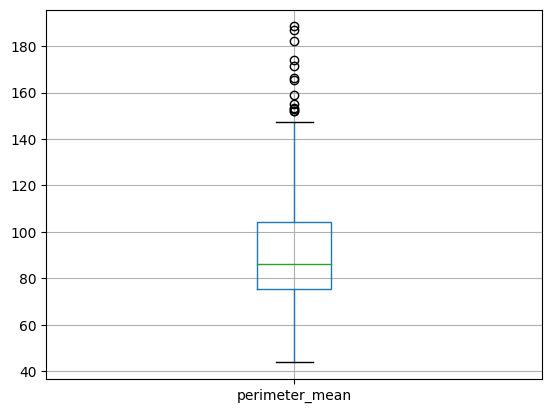

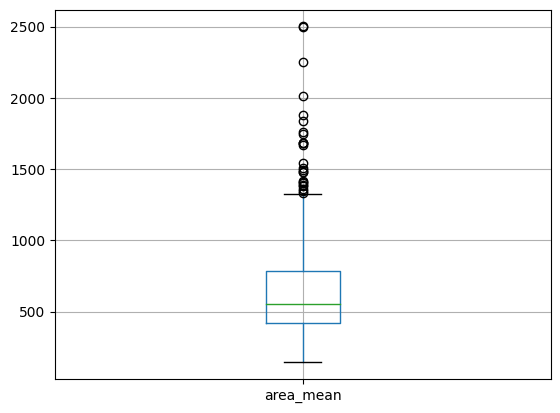

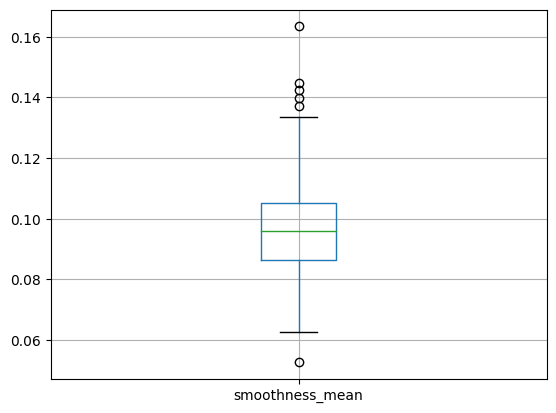

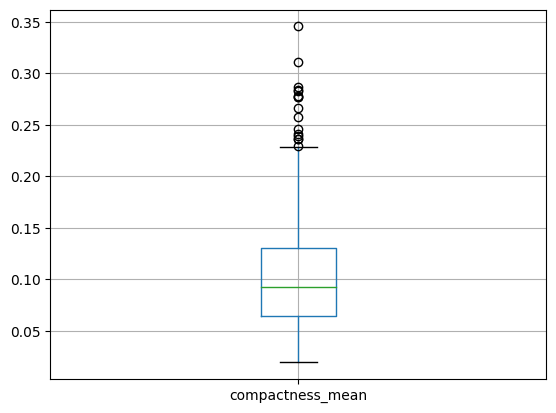

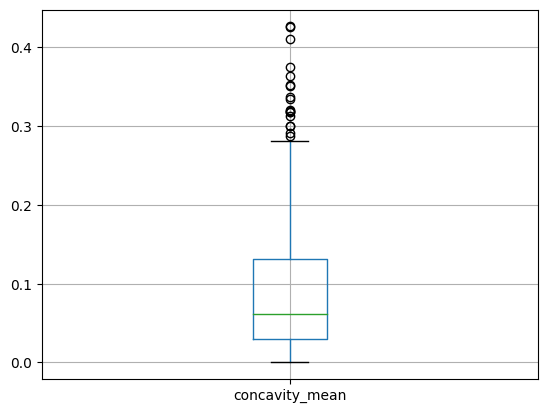

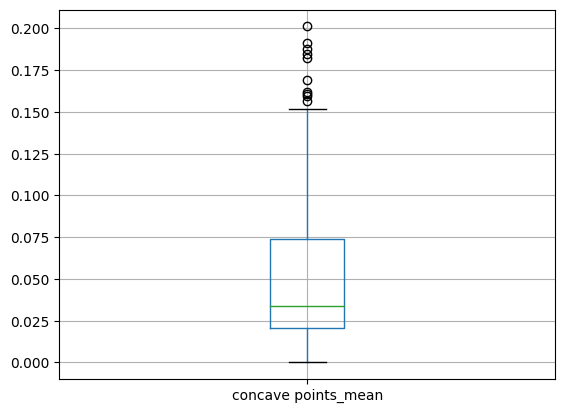

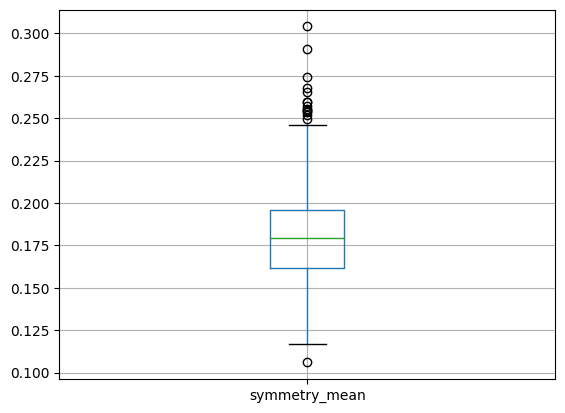

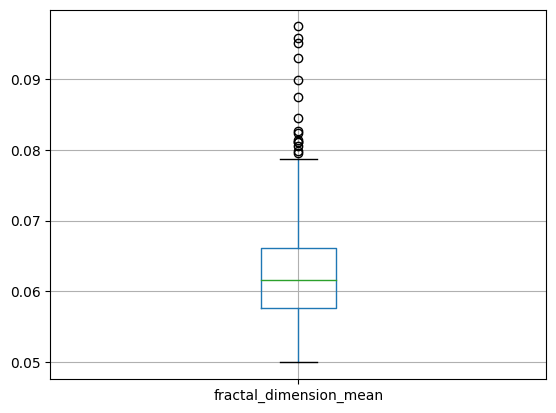

In [9]:
for i in df:
    plt.figure()
    if not (df[i].dtype == object):
        df.boxplot([i])

Since a large number of outliers are data points above the upper whisker, I will just filter them instead of having to consider the outliers in the lower whisker

In [10]:
df_clean = df.copy()
for i in df.columns:
    if not (df[i].dtype == object):
        # calculate interquartile range
        q25, q75 = df[i].quantile(0.25), df[i].quantile(0.75)
        iqr = q75 - q25
        # calculate the outlier cutoff
        cut_off = 1.5*iqr 
        lower, upper = q25 - cut_off, q75 + cut_off
        filter = (df[i] >= lower) & (df[i]<=upper)
        df_clean = df.loc[filter]

In [11]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 554 entries, 0 to 568
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   diagnosis               554 non-null    object 
 1   radius_mean             554 non-null    float64
 2   texture_mean            554 non-null    float64
 3   perimeter_mean          554 non-null    float64
 4   area_mean               554 non-null    float64
 5   smoothness_mean         554 non-null    float64
 6   compactness_mean        554 non-null    float64
 7   concavity_mean          554 non-null    float64
 8   concave points_mean     554 non-null    float64
 9   symmetry_mean           554 non-null    float64
 10  fractal_dimension_mean  554 non-null    float64
dtypes: float64(10), object(1)
memory usage: 51.9+ KB


<Figure size 640x480 with 0 Axes>

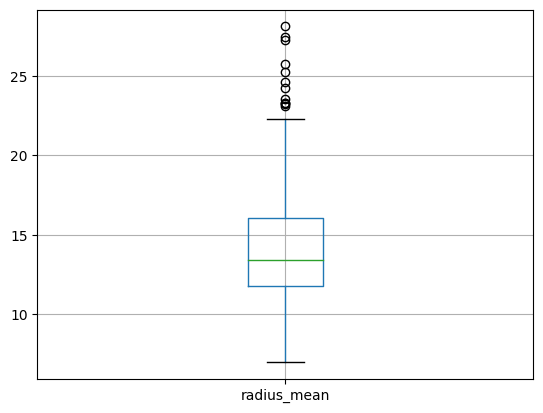

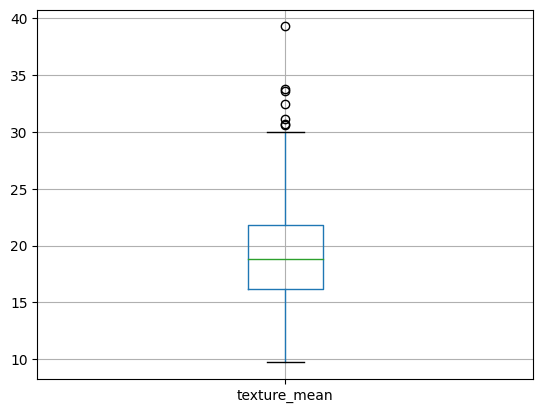

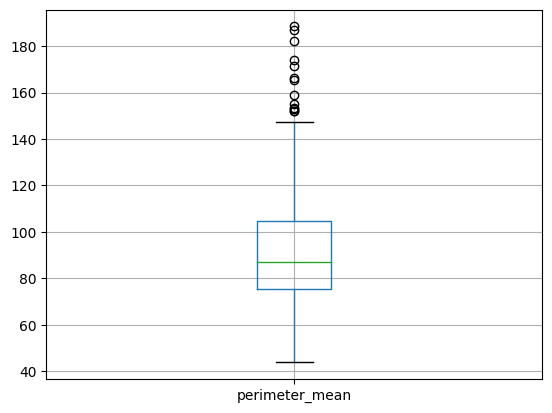

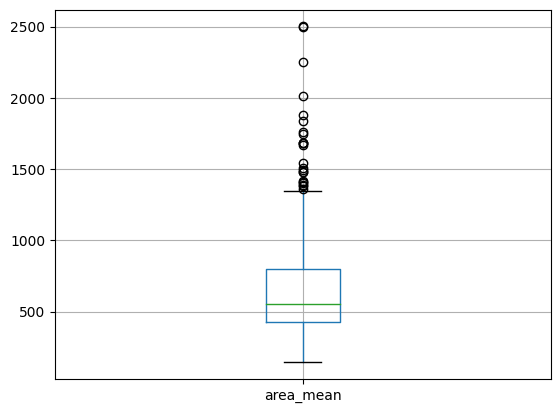

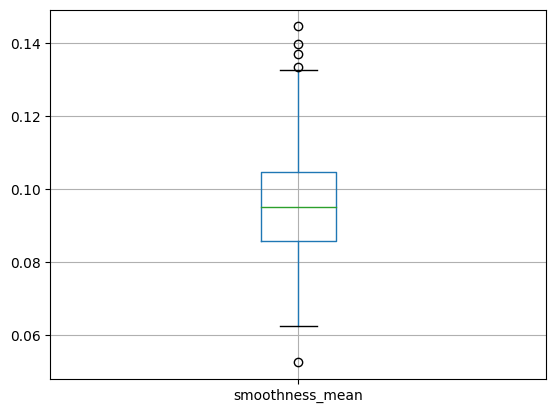

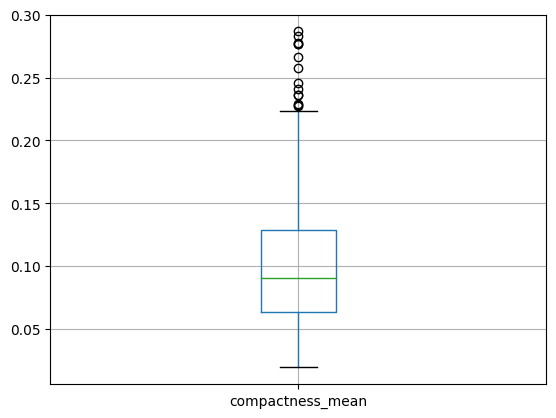

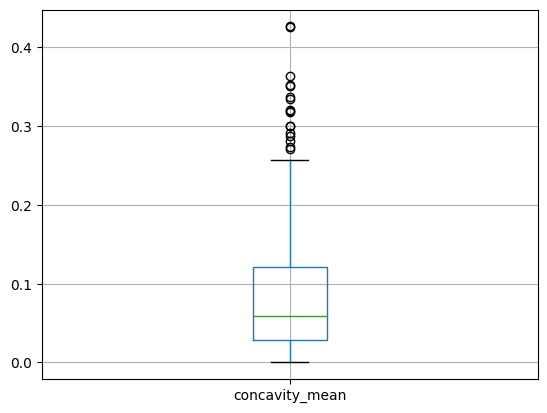

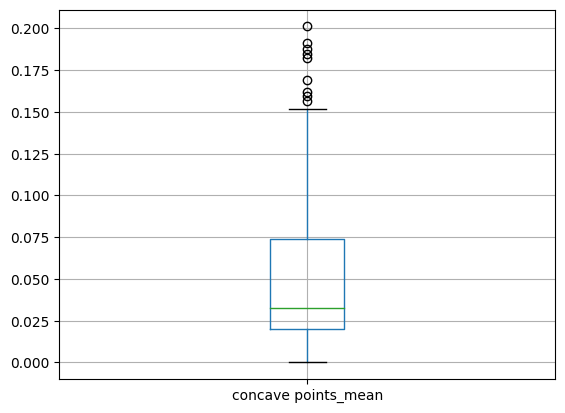

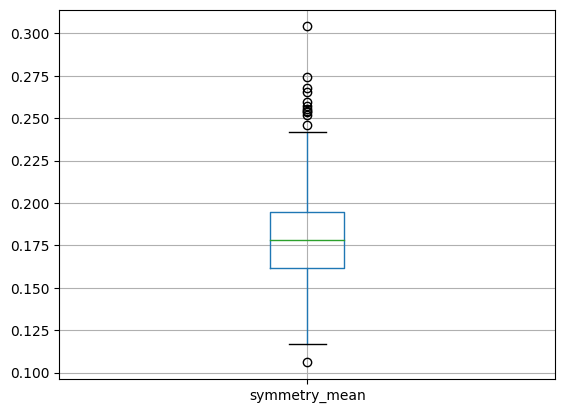

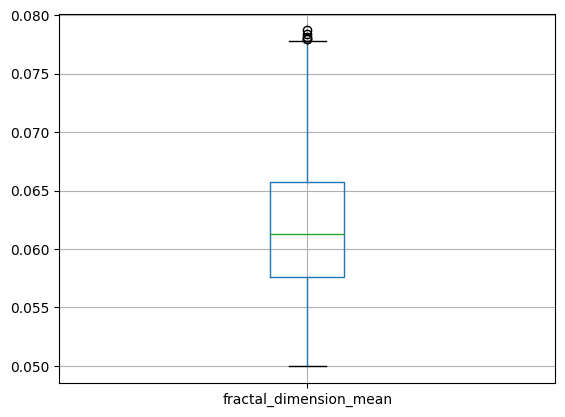

In [12]:
for i in df_clean:
    plt.figure()
    if not (df_clean[i].dtype == object):
        df_clean.boxplot([i])

The data is still noisy, so we should use a soft VSM

In [13]:
#Check if there is any NaN value, but seems there's none
df_clean[df_clean.isna().any(axis=1)]

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean


In [14]:
#Encode the categorical value of "Diagnosis" feature
df_clean['diagnosis'] = df_clean['diagnosis'].apply(lambda x: 0 if x == 'M' else 1)
df_clean.describe()

C:\Users\thomas\AppData\Local\Temp\ipykernel_18156\2469116152.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['diagnosis'] = df_clean['diagnosis'].apply(lambda x: 0 if x == 'M' else 1)


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean
count,554.000000,554.000000,554.000000,554.000000,554.000000,554.000000,554.000000,554.000000,554.000000,554.000000,554.000000
mean,0.626354,14.209823,19.308791,92.446426,661.765884,0.095858,0.101707,0.085634,0.048373,0.180005,0.062167
std,0.484209,3.500176,4.319245,24.158364,351.477136,0.013551,0.049741,0.076411,0.038676,0.026384,0.005920
min,0.000000,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960
25%,0.000000,11.760000,16.172500,75.582500,427.450000,0.085902,0.063732,0.028835,0.020103,0.161800,0.057645
50%,1.000000,13.445000,18.855000,86.965000,556.950000,0.095200,0.090505,0.059285,0.032770,0.178300,0.061325
75%,1.000000,16.027500,21.807500,104.600000,796.650000,0.104875,0.128775,0.121450,0.073580,0.194750,0.065755
max,1.000000,28.110000,39.280000,188.500000,2501.000000,0.144700,0.286700,0.426800,0.201200,0.304000,0.078710


## Split dataset and train soft SVM

In [15]:
# Separate data features by removing the data label.
X = df_clean.drop(columns=["diagnosis"], axis=1)

# Assign data label to variable y
y = df_clean.diagnosis

# Split train/test with a random state
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=10, train_size=0.8)

In [16]:
# Initialize and use StandardScaler to normalize the data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_normalized_train = scaler.fit_transform(X_train)     # Fit and transform thr training data
X_normalized_test = scaler.transform(X_test)           # Only transform the test data.

In [17]:
# SVC is C-Support Vector Classification and its implementation is based on libsvm. The multiclass support is handled according to a one-vs-one scheme.
# Reference: https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html
from sklearn.svm import SVC
model = SVC()
model.fit(X_normalized_train, y_train)

SVC()

In [18]:
# Show evaluation metrics on the test set
from sklearn.metrics import classification_report
print(classification_report(y_test, model.predict(X_normalized_test)))

              precision    recall  f1-score   support

           0       0.97      0.92      0.95        39
           1       0.96      0.99      0.97        72

    accuracy                           0.96       111
   macro avg       0.97      0.95      0.96       111
weighted avg       0.96      0.96      0.96       111



In [19]:
#Chọn các parameters để tiến hành fine-tune (default values của SVM là C=1, gamma=scale, kernel=rbf)
from sklearn.model_selection import GridSearchCV

### Hyper-parameter C is for soft margin SVM. 
# For a large value C, the optimization will chose smaller-margin hyperplane so that there are no misclassified samples in the training data.
# For a small value C, the optimization will chose larger-margin hyperplane even if there are misclassified samples in the training data.

### Hyper-parameter gamma is a parameter for non linear hyperplanes. The higher the gamma value it tries to exactly fit the training data set
param_grid = {"C": [0.01, 0.1, 1, 10, 100, 1000],
              "gamma": ["scale", 0.001, 0.005, 0.1]}
gridsearch = GridSearchCV(SVC(), param_grid, cv=10, scoring="f1", verbose=1)     # cv: number of folds in cross validation.

# Reference: https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html

In [20]:
# Run grid search to find the best set of hyper-parameters
gridsearch.fit(X_normalized_train, y_train)
gridsearch.best_params_

Fitting 10 folds for each of 24 candidates, totalling 240 fits


{'C': 10, 'gamma': 'scale'}

In [21]:
# Re-run SVM with the best set of hyper-parameters.
model = SVC(C=gridsearch.best_params_['C'], gamma=gridsearch.best_params_['gamma'])
model.fit(X_normalized_train, y_train)

SVC(C=10)

In [64]:
# Show evaluation metrics on the test set
predict_SVM = model.predict(X_normalized_test)
print(classification_report(y_test, predict_SVM))

              precision    recall  f1-score   support

           0       0.95      0.95      0.95        39
           1       0.97      0.97      0.97        72

    accuracy                           0.96       111
   macro avg       0.96      0.96      0.96       111
weighted avg       0.96      0.96      0.96       111



## Testing four other models: Linear regression, Logistic regression, Naive Bayes, Decision Tree

### Decision Tree

In [23]:
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

params_dt = {"criterion": ["gini", "entropy"],             # Criterion to evaluate the purity.
         "max_depth": [i for i in range(1, 10)],                           # Maximum depth of the tree
         "min_samples_split": [i for i in range(2, 10)]}                   # Stop splitting condition.

grid_search = GridSearchCV(estimator=DecisionTreeClassifier(), param_grid=params_dt, cv=10, scoring = 'f1')
grid_search.fit(X_normalized_train, y_train)

GridSearchCV(cv=10, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9],
                         'min_samples_split': [2, 3, 4, 5, 6, 7, 8, 9]},
             scoring='f1')

In [24]:
# Build a decision tree model pipeline from the best set of hyper-parameters found
model_dt = DecisionTreeClassifier(criterion=grid_search.best_params_['criterion'], max_depth=grid_search.best_params_['max_depth'], min_samples_split=grid_search.best_params_['min_samples_split'])
# Train the decision tree model
model_dt.fit(X_normalized_train, y_train)

DecisionTreeClassifier(max_depth=4, min_samples_split=4)

In [25]:
# Make prediction on the original test set (after training on the over-sampled training set).
pred_y = model_dt.predict(X_normalized_test)

print(classification_report(y_test, pred_y))

              precision    recall  f1-score   support

           0       0.90      0.95      0.93        39
           1       0.97      0.94      0.96        72

    accuracy                           0.95       111
   macro avg       0.94      0.95      0.94       111
weighted avg       0.95      0.95      0.95       111



### Naive Bayes

In [26]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.preprocessing import PowerTransformer

cv_method = RepeatedStratifiedKFold(n_splits=5, 
                                    n_repeats=10, 
                                    random_state=999)
params_NB = {'var_smoothing': np.logspace(0,-9, num=100)}

naive_model = GaussianNB()
gs_NB = GridSearchCV(estimator=naive_model, 
                     param_grid=params_NB, 
                     cv=cv_method,
                     verbose=1, 
                     scoring='accuracy')

Data_transformed = PowerTransformer().fit_transform(X_normalized_train)
Test_transformed = PowerTransformer().fit_transform(X_normalized_test)

gs_NB.fit(Data_transformed, y_train)

Fitting 50 folds for each of 100 candidates, totalling 5000 fits


GridSearchCV(cv=RepeatedStratifiedKFold(n_repeats=10, n_splits=5, random_state=999),
             estimator=GaussianNB(),
             param_grid={'var_smoothing': array([1.00000000e+00, 8.11130831e-01, 6.57933225e-01, 5.33669923e-01,
       4.32876128e-01, 3.51119173e-01, 2.84803587e-01, 2.31012970e-01,
       1.87381742e-01, 1.51991108e-01, 1.23284674e-01, 1.00000000e-01,
       8.11130831e-02, 6.57933225e-02,...
       1.23284674e-07, 1.00000000e-07, 8.11130831e-08, 6.57933225e-08,
       5.33669923e-08, 4.32876128e-08, 3.51119173e-08, 2.84803587e-08,
       2.31012970e-08, 1.87381742e-08, 1.51991108e-08, 1.23284674e-08,
       1.00000000e-08, 8.11130831e-09, 6.57933225e-09, 5.33669923e-09,
       4.32876128e-09, 3.51119173e-09, 2.84803587e-09, 2.31012970e-09,
       1.87381742e-09, 1.51991108e-09, 1.23284674e-09, 1.00000000e-09])},
             scoring='accuracy', verbose=1)

In [27]:
naive_model = GaussianNB(var_smoothing=gs_NB.best_params_['var_smoothing'])
naive_model.fit(Data_transformed, y_train)
predict_test = naive_model.predict(Test_transformed)
print(classification_report(y_test, predict_test))

              precision    recall  f1-score   support

           0       0.88      0.95      0.91        39
           1       0.97      0.93      0.95        72

    accuracy                           0.94       111
   macro avg       0.93      0.94      0.93       111
weighted avg       0.94      0.94      0.94       111



### Logistic regression

In [28]:
from sklearn.linear_model import LogisticRegressionCV
log_model = LogisticRegressionCV(solver = 'liblinear', class_weight='balanced', verbose=1)
log_model.fit(X_normalized_train, y_train)

[LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear]

[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    0.1s finished


LogisticRegressionCV(class_weight='balanced', solver='liblinear', verbose=1)

In [29]:
log_prediction = log_model.predict(X_normalized_test)
print(classification_report(y_test, log_prediction))

              precision    recall  f1-score   support

           0       0.95      0.92      0.94        39
           1       0.96      0.97      0.97        72

    accuracy                           0.95       111
   macro avg       0.95      0.95      0.95       111
weighted avg       0.95      0.95      0.95       111



### Random forest

In [30]:
# Building a RandomForest is similar to building a decision tree, but there is an additional hyper-parameter called n_estimators which is the number of trees in the forest.
from sklearn.ensemble import RandomForestClassifier

params_rf = {"criterion": ["gini", "entropy"],             # Criterion to evaluate the purity.
         "max_depth": [i for i in range(1, 11)],             # Maximum depth of the tree
         "min_samples_split": [i for i in range(2, 20)]}                   # Stop splitting condition.

cv_method = RepeatedStratifiedKFold(n_splits=5, 
                                    n_repeats=10, 
                                    random_state=999)

grid_search_rf = GridSearchCV(estimator=RandomForestClassifier(n_estimators=10, n_jobs=10), param_grid=params_rf, cv= cv_method) # Number of trees in the forest is 10

# Run the search on oversampled training data samples.
grid_search_rf.fit(X_normalized_train, y_train)     # Train the RandomForest

GridSearchCV(cv=RepeatedStratifiedKFold(n_repeats=10, n_splits=5, random_state=999),
             estimator=RandomForestClassifier(n_estimators=10, n_jobs=10),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
                         'min_samples_split': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11,
                                               12, 13, 14, 15, 16, 17, 18,
                                               19]})

In [31]:
# Build a Random Forest model pipeline from the best set of hyper-parameters found
model_rf = RandomForestClassifier(n_estimators=10, random_state=1, criterion=grid_search_rf.best_params_['criterion'], 
                                  max_depth=grid_search_rf.best_params_['max_depth'], 
                                  min_samples_split=grid_search_rf.best_params_['min_samples_split'])     # Initialize the RandomForest
# Train the Random Forest model
model_rf.fit(X_normalized_train, y_train)

RandomForestClassifier(criterion='entropy', max_depth=9, min_samples_split=7,
                       n_estimators=10, random_state=1)

In [32]:
# Make prediction on the original test set (after training on the over-sampled training set).
pred_rf = model_rf.predict(X_normalized_test)

print(classification_report(y_test, pred_rf))

              precision    recall  f1-score   support

           0       0.92      0.92      0.92        39
           1       0.96      0.96      0.96        72

    accuracy                           0.95       111
   macro avg       0.94      0.94      0.94       111
weighted avg       0.95      0.95      0.95       111



## Model ensemble

In [61]:
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier, VotingClassifier, RandomForestClassifier
from xgboost import XGBClassifier

### Bagging

In [43]:
# Creating a Support Vector Machine Classifier as the base estimator
base_svm = SVC(kernel='linear', C=gridsearch.best_params_['C'], gamma=gridsearch.best_params_['gamma'])
bagging_clf = BaggingClassifier(estimator=base_svm, n_estimators=100, max_samples=0.5)

In [44]:
bagging_clf.fit(X_normalized_train, y_train)

BaggingClassifier(estimator=SVC(C=10, kernel='linear'), max_samples=0.5,
                  n_estimators=100)

In [45]:
predict_bagging = bagging_clf.predict(X_normalized_test)
print(classification_report(y_test, predict_bagging))

              precision    recall  f1-score   support

           0       0.92      0.92      0.92        39
           1       0.96      0.96      0.96        72

    accuracy                           0.95       111
   macro avg       0.94      0.94      0.94       111
weighted avg       0.95      0.95      0.95       111



### Adabost

In [48]:
ada_clf = AdaBoostClassifier(estimator = DecisionTreeClassifier(criterion=grid_search.best_params_['criterion'], 
                                                                max_depth=grid_search.best_params_['max_depth'], 
                                                                min_samples_split=grid_search.best_params_['min_samples_split']), 
                             n_estimators=100)

# Train the AdaBoost Classifier
ada_clf.fit(X_normalized_train, y_train)

# Making predictions on the test set
prediction_ada = ada_clf.predict(X_normalized_test)

print(classification_report(y_test, prediction_ada))

C:\Users\thomas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


              precision    recall  f1-score   support

           0       0.97      0.95      0.96        39
           1       0.97      0.99      0.98        72

    accuracy                           0.97       111
   macro avg       0.97      0.97      0.97       111
weighted avg       0.97      0.97      0.97       111



### XGBoost

In [59]:
xgb_clf = XGBClassifier(n_estimators=100, learning_rate=1e-1)

# Train the XGBoost Classifier
xgb_clf.fit(X_normalized_train, y_train)

# Making predictions on the test set
prediction_xgb = xgb_clf.predict(X_normalized_test)

# Evaluating the accuracy of the model
print(classification_report(y_test, prediction_xgb))

              precision    recall  f1-score   support

           0       0.97      0.92      0.95        39
           1       0.96      0.99      0.97        72

    accuracy                           0.96       111
   macro avg       0.97      0.95      0.96       111
weighted avg       0.96      0.96      0.96       111



### Gradient boosting

In [60]:
gb_clf = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=grid_search.best_params_['max_depth'], 
                                                                min_samples_split=grid_search.best_params_['min_samples_split'])

# Train the Gradient Boosting Classifier
gb_clf.fit(X_normalized_train, y_train)

# Making predictions on the test set
prediction_gb = gb_clf.predict(X_normalized_test)

# Evaluating the accuracy of the model
print(classification_report(y_test, prediction_gb))

              precision    recall  f1-score   support

           0       0.93      0.95      0.94        39
           1       0.97      0.96      0.97        72

    accuracy                           0.95       111
   macro avg       0.95      0.95      0.95       111
weighted avg       0.96      0.95      0.96       111



### Stacking

In [62]:
# Ensemble the four models using hard (majority) voting
estimators=[('decision_tree', model_dt ), ('svm', model), ('rf', model_rf), ('log_reg', log_model)]    # Initialize base models in the ensemble
ensemble = VotingClassifier(estimators, voting='hard')                                      # Define how to ensemble them, i.e., hard voting

In [63]:
# Train the model ensemble on the training set
ensemble.fit(X_normalized_train, y_train)          # Train the ensemble on the training set
prediction_stacking = ensemble.predict(X_normalized_test)
print(classification_report(y_test, prediction_stacking))

[LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear]              precision    recall  f1-score   support

           0       0.90      0.95      0.93        39
           1       0.97      0.94      0.96        72

    accuracy                           0.95       111
   macro avg       0.94      0.95      0.94       111
weighted avg       0.95      0.95      0.95       111



[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    0.0s finished


## Comparison and Conclusion

In [65]:
print('SVM classification report')
print(classification_report(y_test, predict_SVM))
print('Decision tree classification report')
print(classification_report(y_test, pred_y))
print('Naive Bayes classification report')
print(classification_report(y_test, predict_test))
print('Logistic regression classification report')
print(classification_report(y_test, log_prediction))
print('Random forest classification report')
print(classification_report(y_test, pred_rf))
print('Model ensemble - Bagging classification report')
print(classification_report(y_test, predict_bagging))
print('Model ensemble - AdaBoost classification report')
print(classification_report(y_test, prediction_ada))
print('Model ensemble - XGBoost classification report')
print(classification_report(y_test, prediction_xgb))
print('Model ensemble - Gradient boosting classification report')
print(classification_report(y_test, prediction_gb))
print('Model ensemble - Stacking classification report')
print(classification_report(y_test, prediction_stacking))

SVM classification report
              precision    recall  f1-score   support

           0       0.95      0.95      0.95        39
           1       0.97      0.97      0.97        72

    accuracy                           0.96       111
   macro avg       0.96      0.96      0.96       111
weighted avg       0.96      0.96      0.96       111

Decision tree classification report
              precision    recall  f1-score   support

           0       0.90      0.95      0.93        39
           1       0.97      0.94      0.96        72

    accuracy                           0.95       111
   macro avg       0.94      0.95      0.94       111
weighted avg       0.95      0.95      0.95       111

Naive Bayes classification report
              precision    recall  f1-score   support

           0       0.88      0.95      0.91        39
           1       0.97      0.93      0.95        72

    accuracy                           0.94       111
   macro avg       0.93      0.9